In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import geopandas as gpd

import matplotlib.pyplot as plt

from drawarrow import ax_arrow
from highlight_text import ax_text


## Load crop insurance data

I am using [state / county / crop summary of business](https://www.rma.usda.gov/tools-reports/summary-of-business/state-county-crop-summary-business) data from 1948 - 2026. 

### Crop insurance data from 1948 - 1988

The crop insurance data from this time period comes in a single text file.

In [2]:
CROP = 'wheat'
PROJECT_ROOT = Path('.').resolve().parent
INPUT_DIR = PROJECT_ROOT / 'data' / 'processed'

df = pd.read_parquet(f'{INPUT_DIR}/usda_crop_insurance_1948_2026.parquet')
df = df.query(" commodity_name.str.contains(@CROP) and commodity_name != 'buckwheat' ").reset_index(drop=True)

assert(df.commodity_year.min() == 1948 and df.commodity_year.max() == 2026)

df


,commodity_year,state,fips,county_name,commodity_code,commodity_name,policies_sold,policies_premium,policies_indemnified,units_premium,...,insurance_code,insurance_name,coverage_category,delivery_type,coverage_level,quantity_type,endorsed_acres,state_private_subsidy,additional_subsidy,efa_premium_discount
0,1948,CA,06079,SAN LUIS OBISPO,0011,wheat,122,96,0,201.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1948,CA,06101,SUTTER,0011,wheat,126,56,0,75.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1948,CA,06107,TULARE,0011,wheat,58,44,0,184.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1948,CO,08001,ADAMS,0011,wheat,23,20,0,44.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1948,CO,08009,BACA,0011,wheat,29,25,0,88.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
634912,2026,WY,56031,Platte,0011,wheat,2,2,0,4.0,...,01,YP,A,RBUP,.6000,Acres,0.0,0.0,0.0,0.0
634913,2026,WY,56031,Platte,0011,wheat,1,1,0,1.0,...,01,YP,A,RBUP,.6500,Acres,0.0,0.0,0.0,0.0
634914,2026,WY,56031,Platte,0011,wheat,3,1,0,2.0,...,01,YP,A,RBUP,.7000,Acres,0.0,0.0,0.0,0.0
634915,2026,WY,56031,Platte,0011,wheat,3,0,0,0.0,...,01,YP,A,RBUP,.7500,Acres,0.0,0.0,0.0,0.0


In [3]:
# NOTE: we are only filtering the data since 1990 this for stats / figures purposes
df = df.query(" commodity_year >= 1990 ")
df


,commodity_year,state,fips,county_name,commodity_code,commodity_name,policies_sold,policies_premium,policies_indemnified,units_premium,...,insurance_code,insurance_name,coverage_category,delivery_type,coverage_level,quantity_type,endorsed_acres,state_private_subsidy,additional_subsidy,efa_premium_discount
39252,1990,AL,01003,Baldwin,0011,wheat,3,0,0,0.0,...,90,APH,E,RBUP,.0000,Acres,0.0,0.0,0.0,0.0
39253,1990,AL,01003,Baldwin,0011,wheat,5,5,2,14.0,...,90,APH,E,FBUP,.6500,Acres,0.0,0.0,0.0,0.0
39254,1990,AL,01003,Baldwin,0011,wheat,10,10,6,16.0,...,90,APH,E,RBUP,.6500,Acres,0.0,0.0,0.0,0.0
39255,1990,AL,01003,Baldwin,0011,wheat,3,3,2,8.0,...,90,APH,E,FBUP,.7500,Acres,0.0,0.0,0.0,0.0
39256,1990,AL,01003,Baldwin,0011,wheat,1,1,0,5.0,...,90,APH,E,RBUP,.7500,Acres,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
634912,2026,WY,56031,Platte,0011,wheat,2,2,0,4.0,...,01,YP,A,RBUP,.6000,Acres,0.0,0.0,0.0,0.0
634913,2026,WY,56031,Platte,0011,wheat,1,1,0,1.0,...,01,YP,A,RBUP,.6500,Acres,0.0,0.0,0.0,0.0
634914,2026,WY,56031,Platte,0011,wheat,3,1,0,2.0,...,01,YP,A,RBUP,.7000,Acres,0.0,0.0,0.0,0.0
634915,2026,WY,56031,Platte,0011,wheat,3,0,0,0.0,...,01,YP,A,RBUP,.7500,Acres,0.0,0.0,0.0,0.0


In [4]:
print('Commodity names:')
print(f'{df.commodity_name.values.unique().tolist()}')
print()

print('Commodity codes:')
print(f'{df.commodity_code.values.unique().tolist()}')
print()

print(f'States growing {CROP}:')
print(f'{sorted(df.state.values.unique().tolist())}')
print()

print('Insurance plans:')
print(f'{sorted(df.insurance_name.values.unique().fillna('').astype('str').tolist())}')
print()

print('Insurance codes:')
print(f'{sorted(df.insurance_code.values.unique().fillna('').astype('str').tolist())}')
print()


Commodity names:
['wheat', 'grp wheat', 'income protection wheat', 'hybrid wheat seed']

Commodity codes:
['0011', '0111', '0311', '1011']

States growing wheat:
['AL', 'AR', 'AZ', 'CA', 'CO', 'DE', 'FL', 'GA', 'IA', 'ID', 'IL', 'IN', 'KS', 'KY', 'LA', 'MD', 'ME', 'MI', 'MN', 'MO', 'MS', 'MT', 'NC', 'ND', 'NE', 'NJ', 'NM', 'NV', 'NY', 'OH', 'OK', 'OR', 'PA', 'SC', 'SD', 'TN', 'TX', 'UT', 'VA', 'VT', 'WA', 'WI', 'WV', 'WY']

Insurance plans:
['APH', 'ARP', 'ARP - HPE', 'AYP', 'CLIP', 'CRC', 'ECO-RP', 'ECO-RPHPE', 'ECO-YP', 'GRIP', 'GRIP-HRO', 'GRIPH', 'GRP', 'HIP-WI', 'IP', 'MCO-RP', 'MP', 'MP-HPO', 'RA', 'RP', 'RPHPE', 'SCO-RP', 'SCO-RPHPE', 'SCO-YP', 'YDO', 'YP']

Insurance codes:
['01', '02', '03', '04', '05', '06', '12', '16', '17', '25', '31', '32', '33', '37', '42', '44', '55', '68', '73', '77', '87', '88', '89', '90']



The *grp wheat* and *income protection wheat* values are in the `commodity_name` column are insurance plans. In our case, there are several thousand rows of these policies, but still  make up less than 1% of our dataset.


In [5]:
only_insurance = df.query(" commodity_code == '0111' or commodity_code == '0311' ")
assert(only_insurance.endorsed_acres.all() == 0)
only_insurance


,commodity_year,state,fips,county_name,commodity_code,commodity_name,policies_sold,policies_premium,policies_indemnified,units_premium,...,insurance_code,insurance_name,coverage_category,delivery_type,coverage_level,quantity_type,endorsed_acres,state_private_subsidy,additional_subsidy,efa_premium_discount
58731,1994,KS,20061,Geary,0111,grp wheat,11,11,0,11.0,...,12,GRP,E,RBUP,.6500,Acres,0.0,0.0,0.0,0.0
58798,1994,KS,20085,Jackson,0111,grp wheat,4,0,0,0.0,...,12,GRP,E,RBUP,.0000,Acres,0.0,0.0,0.0,0.0
58799,1994,KS,20085,Jackson,0111,grp wheat,4,4,0,4.0,...,12,GRP,E,RBUP,.6500,Acres,0.0,0.0,0.0,0.0
58818,1994,KS,20091,Johnson,0111,grp wheat,18,18,0,18.0,...,12,GRP,E,RBUP,.6500,Acres,0.0,0.0,0.0,0.0
58841,1994,KS,20099,Labette,0111,grp wheat,21,21,0,21.0,...,12,GRP,E,RBUP,.6500,Acres,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82888,1996,ND,38035,Grand Forks,0311,income protection wheat,26,24,2,24.0,...,42,IP,A,RBUP,.0000,Acres,0.0,0.0,0.0,0.0
82889,1996,ND,38035,Grand Forks,0311,income protection wheat,7,7,0,7.0,...,42,IP,L,RBUP,.0000,Acres,0.0,0.0,0.0,0.0
83056,1996,ND,38067,Pembina,0311,income protection wheat,14,14,1,14.0,...,42,IP,A,RBUP,.0000,Acres,0.0,0.0,0.0,0.0
83222,1996,ND,38099,Walsh,0311,income protection wheat,20,20,6,20.0,...,42,IP,A,RBUP,.0000,Acres,0.0,0.0,0.0,0.0


## Load in state and county boundaries from theme

In [6]:
world_states_url = 'https://naciscdn.org/naturalearth/10m/cultural/ne_10m_admin_1_states_provinces_lakes.zip'
world_states = gpd.read_file(world_states_url)
states = world_states.query(" adm0_a3 == 'USA' ")
states = states[['name', 'postal', 'geometry']]
states.columns = ['name', 'state', 'geometry']
states = states.query(" state != 'AK' and state != 'DC' and state != 'HI' ")
states = states.sort_values(by='state').reset_index(drop=True)
states


,name,state,geometry
0,Alabama,AL,"MULTIPOLYGON (((-87.41958 30.4796, -87.42683 3..."
1,Arkansas,AR,"POLYGON ((-90.30422 35.00008, -90.30124 34.995..."
2,Arizona,AZ,"POLYGON ((-111.00627 31.32718, -111.06712 31.3..."
3,California,CA,"MULTIPOLYGON (((-114.72428 32.71284, -114.7645..."
4,Colorado,CO,"POLYGON ((-109.04633 40.99983, -108.88932 40.9..."
5,Connecticut,CT,"POLYGON ((-73.6417 41.00177, -73.64286 41.0010..."
6,Delaware,DE,"POLYGON ((-75.05809 38.45372, -75.06273 38.457..."
7,Florida,FL,"MULTIPOLYGON (((-87.44734 30.31314, -87.46443 ..."
8,Georgia,GA,"MULTIPOLYGON (((-80.89029 32.03266, -80.88939 ..."
9,Iowa,IA,"POLYGON ((-96.48266 42.51834, -96.48217 42.553..."


In [7]:
counties_url = 'https://naciscdn.org/naturalearth/10m/cultural/ne_10m_admin_2_counties_lakes.zip'
counties = gpd.read_file(counties_url)

counties = counties[['NAME', 'NAME_ALT', 'REGION', 'FIPS', 'geometry']]
counties.columns = ['name', 'name_alt', 'region', 'fips', 'geometry']

# remove the 'US' value prepended to the fips codes
counties['fips'] = [fips[2:] for fips in counties.fips]

# we want to exclude alaska, d.c., hawaii, puerto rico, and the usa virgin islands here
counties = counties.query(" region != 'AK' and region != 'DC' and region != 'HI' and region != 'PR' and region != 'VI' ")
counties.rename(columns={'region':'state'}, inplace=True)
counties


,name,name_alt,state,fips,geometry
0,Whatcom,Whatcom County,WA,53073,"MULTIPOLYGON (((-122.75302 48.99251, -122.6532..."
1,Okanogan,Okanogan County,WA,53047,"POLYGON ((-120.85196 48.99251, -120.67495 48.9..."
2,Ferry,Ferry County,WA,53019,"POLYGON ((-118.83688 48.99251, -118.69668 48.9..."
3,Stevens,Stevens County,WA,53065,"POLYGON ((-118.21996 48.99251, -118.03723 48.9..."
4,Pend Oreille,Pend Oreille County,WA,53051,"POLYGON ((-117.42951 48.99251, -117.37787 48.9..."
...,...,...,...,...,...
3185,Washakie,Washakie County,WY,56043,"POLYGON ((-108.55055 44.16845, -108.19008 44.1..."
3186,Fremont,Fremont County,WY,56013,"POLYGON ((-107.52291 42.43435, -107.52271 42.2..."
3187,Natrona,Natrona County,WY,56025,"POLYGON ((-106.07584 42.43321, -106.32218 42.4..."
3188,Hot Springs,Hot Springs County,WY,56017,"POLYGON ((-107.59509 43.50139, -107.59512 43.4..."


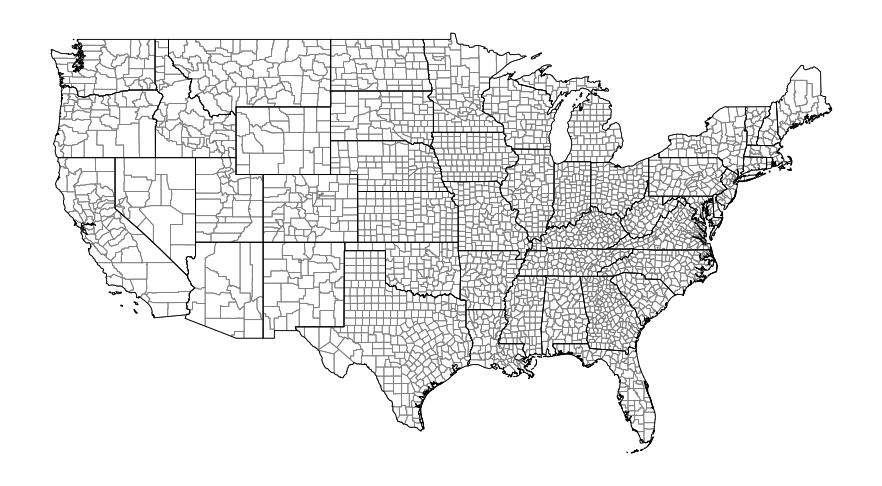

In [8]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=120)

counties.plot(facecolor='none', edgecolor='gray', linewidth=0.5, ax=ax)
states.plot(facecolor='none', edgecolor='black', linewidth=0.5, ax=ax)

ax.axis('off')

plt.show()


## Analyzing premiums and subsidies

In [9]:
premiums_subsidies_indemnities = df[['commodity_year', 'total_premium', 'subsidy', 'indemnity']].groupby(by='commodity_year').sum().reset_index(drop=False)
premiums_subsidies_indemnities.head()


,commodity_year,total_premium,subsidy,indemnity
0,1990,178040771.0,46966276.0,153204414.0
1,1991,115544303.0,30305306.0,158243721.0
2,1992,144201992.0,38472435.0,197828466.0
3,1993,143358983.0,38984914.0,238403737.0
4,1994,157124581.0,43222355.0,186237701.0


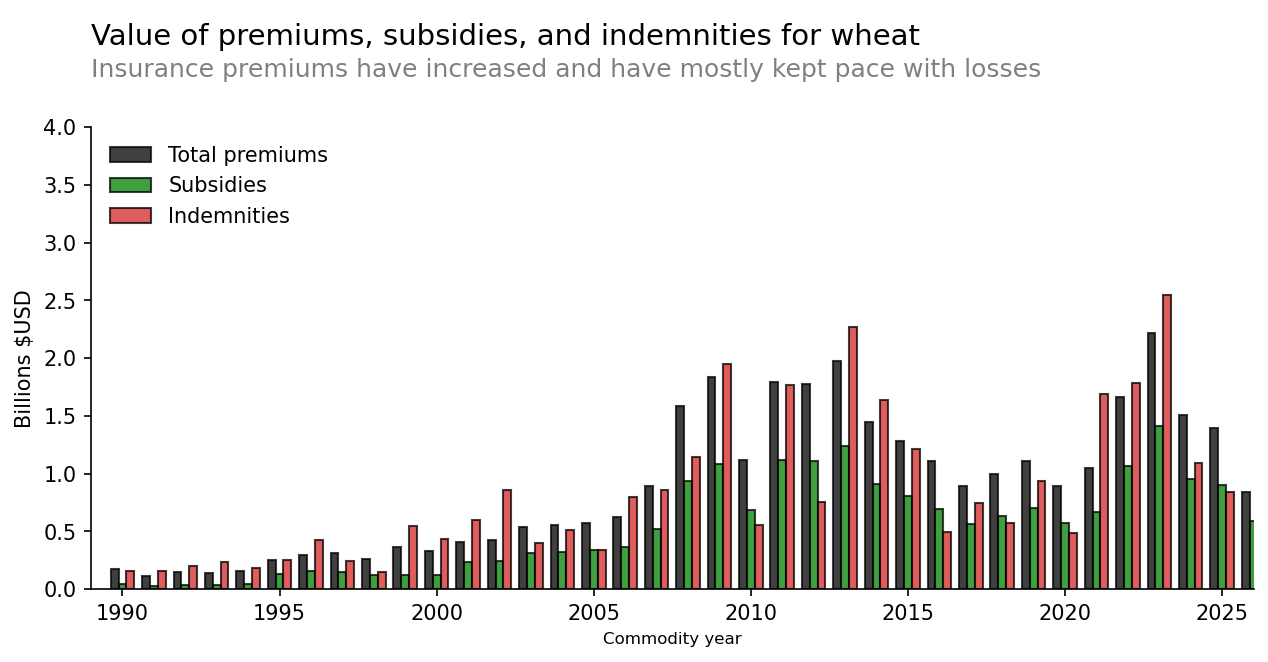

In [10]:
width = 0.25
multiplier = -1
x = premiums_subsidies_indemnities.commodity_year.values

arrow_props = dict(
    color='black', 
    width=0.5, 
    head_width=2, 
    head_length=5,
)

fig, ax = plt.subplots(figsize=(10, 4), dpi=150)

for col, values in premiums_subsidies_indemnities.drop('commodity_year', axis=1).items():

    if col == 'total_premium':
        color = 'black'
        label = 'Total premiums'
    elif col == 'subsidy':
        color = 'green'
        label = 'Subsidies'
    else:
        color = 'tab:red'
        label = 'Indemnities'
    
    offset = width * multiplier
    
    rects = ax.bar(
        x + offset, values, 
        width, 
        color=color,
        edgecolor='black', 
        alpha=0.75,
        label=label,
    )
    
    multiplier += 1

ax.set_xlabel('Commodity year', size=8)

ax.set_xlim([1989, 2026])
ax.set_yticks(ticks=np.arange(0, 4.5e9, 0.5e9), labels=np.arange(0, 4.5, 0.5))
ax.set_ylabel('Billions $USD')

ax.legend(loc='upper left', frameon=False)

s = f'Value of premiums, subsidies, and indemnities for {CROP}'
ax_text(x=1989, y=4.9e9, s=s, size=14, ha='left')

s = 'Insurance premiums have increased and have mostly kept pace with losses'
ax_text(x=1989, y=4.6e9, s=s, size=12, color='gray', ha='left')

ax.spines[['top', 'right']].set_visible(False)

plt.show()


## Indemnities

### By time

In [11]:
val_indemnities_by_year = df[['commodity_year', 'indemnity']].groupby(by='commodity_year').sum().reset_index(drop=False)
val_indemnities_by_year


,commodity_year,indemnity
0,1990,1.532044e+08
1,1991,1.582437e+08
2,1992,1.978285e+08
3,1993,2.384037e+08
4,1994,1.862377e+08
5,1995,2.494097e+08
6,1996,4.286385e+08
7,1997,2.465884e+08
8,1998,1.512762e+08
9,1999,5.496928e+08


In [12]:
val_indemnities_by_state_and_year = df[['state', 'commodity_year', 'indemnity']].groupby(by=['state', 'commodity_year']).sum()
val_indemnities_by_state_and_year = val_indemnities_by_state_and_year.reset_index()
val_indemnities_by_state_and_year


,state,commodity_year,indemnity
0,AL,1990,437383.0
1,AL,1991,274589.0
2,AL,1992,65439.0
3,AL,1993,127996.0
4,AL,1994,33870.0
...,...,...,...
1562,WY,2022,6988840.0
1563,WY,2023,5384837.0
1564,WY,2024,5515746.0
1565,WY,2025,5664841.0


### By state

In [13]:
num_indemnities_by_state = df[['state', 'policies_indemnified']].groupby(by='state').sum()
num_indemnities_by_state = num_indemnities_by_state.sort_values(by='policies_indemnified', ascending=False).reset_index()
num_indemnities_by_state = num_indemnities_by_state.merge(states, on='state', how='left')[['state', 'name', 'policies_indemnified', 'geometry']]
num_indemnities_by_state = gpd.GeoDataFrame(num_indemnities_by_state).set_geometry('geometry')
num_indemnities_by_state = num_indemnities_by_state.query(" policies_indemnified > 0 ")
num_indemnities_by_state


,state,name,policies_indemnified,geometry
0,KS,Kansas,553189,"POLYGON ((-102.03957 36.99981, -102.03994 37.0..."
1,ND,North Dakota,289616,"POLYGON ((-104.04757 48.99262, -103.96949 48.9..."
2,TX,Texas,257592,"MULTIPOLYGON (((-103.31151 29.02604, -103.3099..."
3,OK,Oklahoma,199088,"POLYGON ((-103.00024 36.5002, -103.00036 36.62..."
4,MT,Montana,113157,"POLYGON ((-116.04816 48.99251, -115.83913 48.9..."
5,NE,Nebraska,112880,"POLYGON ((-104.05373 40.99983, -104.05292 41.1..."
6,SD,South Dakota,105740,"POLYGON ((-104.05666 45.0001, -104.0393 44.999..."
7,CO,Colorado,100351,"POLYGON ((-109.04633 40.99983, -108.88932 40.9..."
8,WA,Washington,60634,"MULTIPOLYGON (((-122.75302 48.99251, -122.6532..."
9,MN,Minnesota,58113,"POLYGON ((-97.22609 48.99267, -97.15538 48.992..."


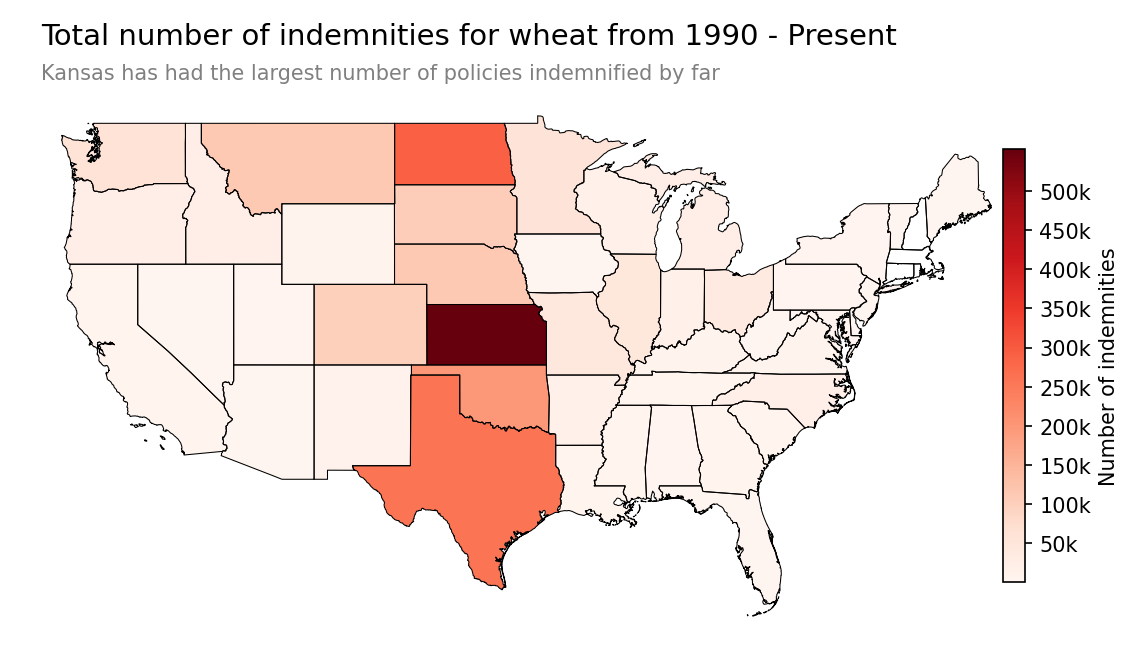

In [14]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=150)

num_indemnities_by_state.plot(column='policies_indemnified', cmap='Reds', ax=ax)
states.plot(facecolor='none', edgecolor='black', linewidth=0.5, ax=ax)

vmin = num_indemnities_by_state['policies_indemnified'].min()
vmax = num_indemnities_by_state['policies_indemnified'].max()
norm = plt.Normalize(vmin=vmin, vmax=vmax)
mapper = plt.cm.ScalarMappable(cmap='Reds', norm=norm)

cbar = plt.colorbar(mapper, shrink=0.75, ax=ax, pad=-0.03)
cbar.set_ticks(np.arange(50000, 550000, 50000))
cbar.set_ticklabels([str(val)+'k' for val in np.arange(50, 550, 50)])
cbar.set_label('Number of indemnities')

s = f'Total number of indemnities for {CROP} from 1990 - Present'
ax_text(x=-126, y=54, s=s, size=14, color='black', ha='left')

s = 'Kansas has had the largest number of policies indemnified by far'
ax_text(x=-126, y=52, s=s, size=10, color='gray', ha='left')
ax.axis('off')

plt.show()


In [15]:
val_indemnities_by_state = df[['state', 'indemnity']].groupby(by='state').sum()
val_indemnities_by_state = val_indemnities_by_state.sort_values(by='indemnity', ascending=False).reset_index()
val_indemnities_by_state = val_indemnities_by_state.merge(states, on='state', how='left')[['state', 'name', 'indemnity', 'geometry']]
val_indemnities_by_state = gpd.GeoDataFrame(val_indemnities_by_state).set_geometry('geometry')
val_indemnities_by_state = val_indemnities_by_state.query(" indemnity > 0 ")
val_indemnities_by_state


,state,name,indemnity,geometry
0,ND,North Dakota,5.260756e+09,"POLYGON ((-104.04757 48.99262, -103.96949 48.9..."
1,KS,Kansas,5.024918e+09,"POLYGON ((-102.03957 36.99981, -102.03994 37.0..."
2,TX,Texas,3.417400e+09,"MULTIPOLYGON (((-103.31151 29.02604, -103.3099..."
3,OK,Oklahoma,2.711585e+09,"POLYGON ((-103.00024 36.5002, -103.00036 36.62..."
4,MT,Montana,2.710498e+09,"POLYGON ((-116.04816 48.99251, -115.83913 48.9..."
5,WA,Washington,1.660836e+09,"MULTIPOLYGON (((-122.75302 48.99251, -122.6532..."
6,CO,Colorado,1.629166e+09,"POLYGON ((-109.04633 40.99983, -108.88932 40.9..."
7,SD,South Dakota,1.541281e+09,"POLYGON ((-104.05666 45.0001, -104.0393 44.999..."
8,NE,Nebraska,8.169598e+08,"POLYGON ((-104.05373 40.99983, -104.05292 41.1..."
9,ID,Idaho,7.837711e+08,"POLYGON ((-117.03815 48.99251, -116.93818 48.9..."


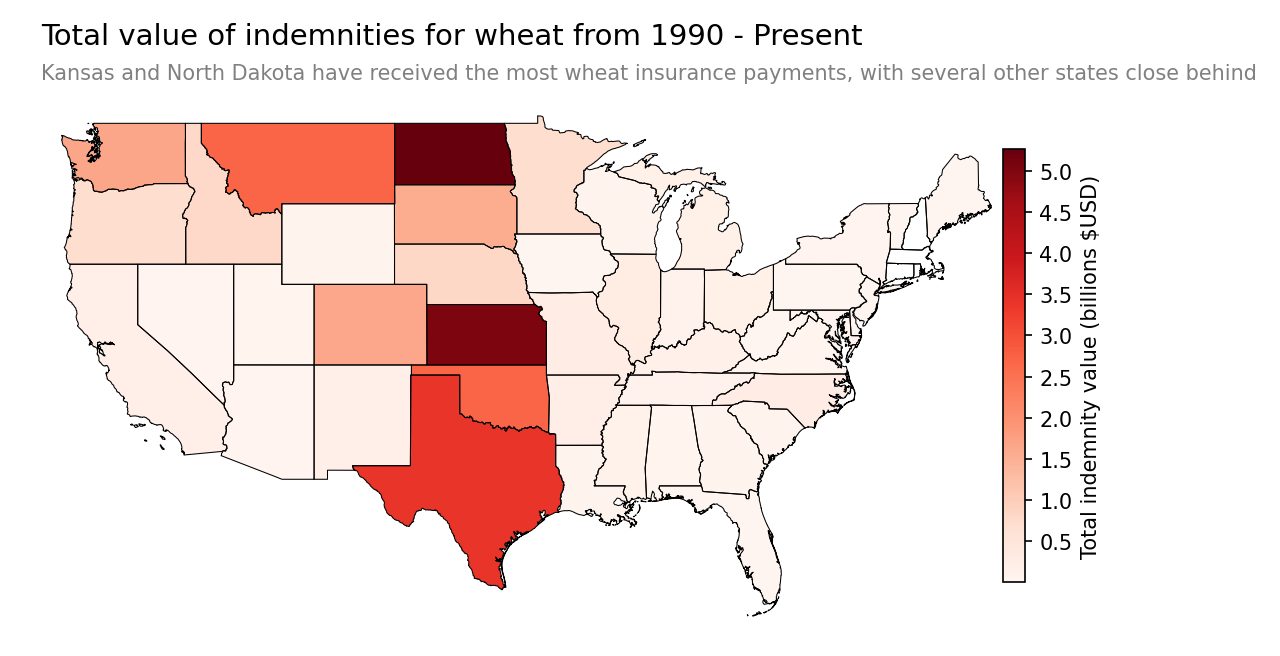

In [16]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=150)

val_indemnities_by_state.plot(column='indemnity', cmap='Reds', ax=ax)
states.plot(facecolor='none', edgecolor='black', linewidth=0.5, ax=ax)

vmin = val_indemnities_by_state['indemnity'].min()
vmax = val_indemnities_by_state['indemnity'].max()
norm = plt.Normalize(vmin=vmin, vmax=vmax)
mapper = plt.cm.ScalarMappable(cmap='Reds', norm=norm)
cbar = plt.colorbar(mapper, shrink=0.75, ax=ax, pad=-0.03)
cbar.set_ticks(np.arange(0.5e9, 5.5e9, 0.5e9))
cbar.set_ticklabels([f'{val:.1f}' for val in np.arange(0.5, 5.50, 0.5)])
cbar.set_label('Total indemnity value (billions $USD)', fontsize=10)

s = f'Total value of indemnities for {CROP} from 1990 - Present'
ax_text(x=-126, y=54, s=s, size=14, color='black', ha='left')

s = f'Kansas and North Dakota have received the most {CROP} insurance payments, with several other states close behind'
ax_text(x=-126, y=52, s=s, size=10, color='gray', ha='left')

ax.axis('off')

plt.show()


Interesting! So Kansas has a higher number of indemnities than North Dakota since 1990, but North Dakota has had costlier insurance payments in that same time period.

### By county

In [17]:
num_indemnities_by_county = df[['fips', 'county_name', 'policies_indemnified']].groupby(by=['fips', 'county_name']).sum()
num_indemnities_by_county = num_indemnities_by_county.sort_values(by='policies_indemnified', ascending=False).reset_index()
num_indemnities_by_county = num_indemnities_by_county.merge(counties, on='fips', how='left')[['state', 'name', 'fips', 'policies_indemnified', 'geometry']]
num_indemnities_by_county = gpd.GeoDataFrame(num_indemnities_by_county).set_geometry('geometry')
num_indemnities_by_county = num_indemnities_by_county.query(" policies_indemnified > 0 ")
num_indemnities_by_county


,state,name,fips,policies_indemnified,geometry
0,KS,Sumner,20191,17521,"POLYGON ((-97.14771 36.99981, -97.15995 36.999..."
1,OK,Texas,40139,16971,"POLYGON ((-100.95431 36.50014, -100.9957 36.50..."
2,OK,Grant,40053,16162,"POLYGON ((-97.80231 36.99981, -97.62214 36.999..."
3,KS,Barton,20009,14907,"POLYGON ((-98.4861 38.69687, -98.47995 38.6967..."
4,ND,Cavalier,38019,13317,"POLYGON ((-98.99979 48.99267, -98.91385 48.992..."
...,...,...,...,...,...
2056,MS,Lafayette,28071,1,"POLYGON ((-89.24556 34.50889, -89.24633 34.379..."
2057,CO,Routt,08107,1,"POLYGON ((-107.31906 40.99983, -107.16205 40.9..."
2058,GA,Walton,13297,1,"POLYGON ((-83.7991 33.92984, -83.76469 33.8986..."
2059,IA,Clayton,19043,1,"POLYGON ((-91.15996 43.07971, -91.15466 43.056..."


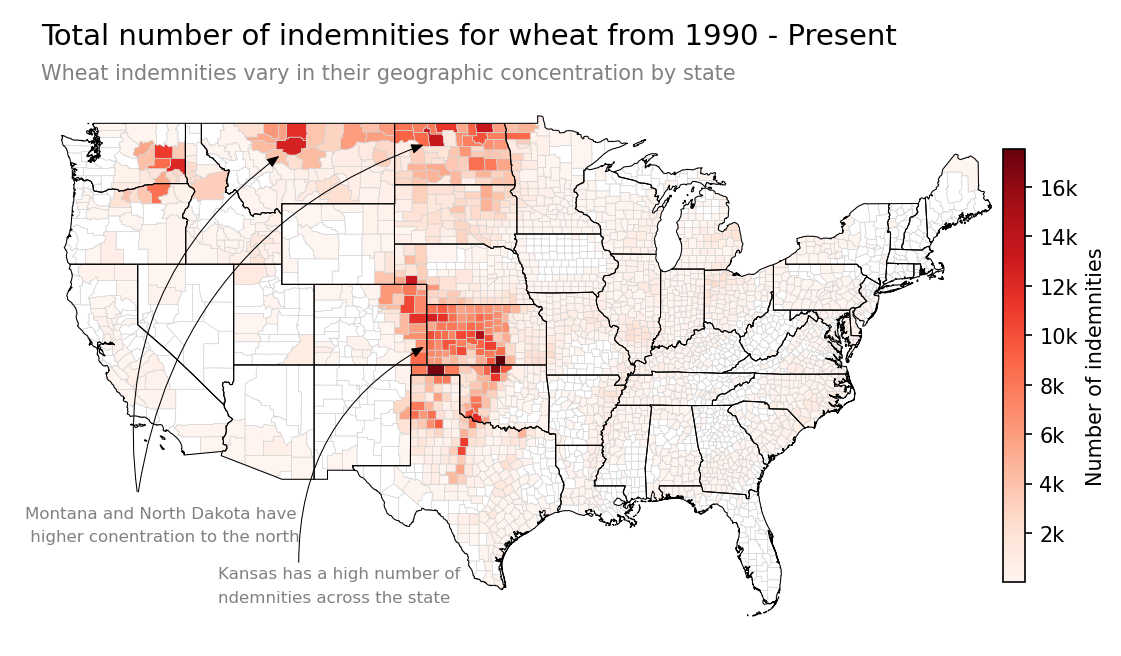

In [18]:
arrow_props = dict(
    color='black', 
    width=0.5, 
    head_width=2, 
    head_length=5,
)

fig, ax = plt.subplots(figsize=(10, 5), dpi=150)

num_indemnities_by_county.plot(column='policies_indemnified', cmap='Reds', ax=ax)
counties.plot(facecolor='none', edgecolor='lightgray', linewidth=0.25, ax=ax)
states.plot(facecolor='none', edgecolor='black', linewidth=0.5, ax=ax)

vmin = num_indemnities_by_county['policies_indemnified'].min()
vmax = num_indemnities_by_county['policies_indemnified'].max()
norm = plt.Normalize(vmin=vmin, vmax=vmax)
mapper = plt.cm.ScalarMappable(cmap='Reds', norm=norm)

cbar = plt.colorbar(mapper, shrink=0.75, ax=ax, pad=-0.03)
cbar.set_ticks(np.arange(2000, 18000, 2000))
cbar.set_ticklabels([str(val)+'k' for val in np.arange(2, 18, 2)])
cbar.set_label('Number of indemnities')

s = f'Total number of indemnities for {CROP} from 1990 - Present'
ax_text(x=-126, y=54, s=s, size=14, color='black', ha='left')

s = f'{CROP.title()} indemnities vary in their geographic concentration by state'
ax_text(x=-126, y=52, s=s, size=10, color='gray', ha='left')

s = f'Kansas has a high number of\nndemnities across the state'
ax_text(x=-115, y=27, s=s, size=8, color='gray', ha='left')
ax_arrow(tail_position=(-110, 27), head_position=(-102, 38), radius=0.3, invert=True, **arrow_props)


s = f'Montana and North Dakota have\n higher conentration to the north'
ax_text(x=-127, y=30, s=s, size=8, color='gray', ha='left')
ax_arrow(tail_position=(-120, 30.5), head_position=(-111, 47.5), radius=0.3, invert=True, **arrow_props)
ax_arrow(tail_position=(-120, 30.5), head_position=(-102, 48), radius=0.3, invert=True, **arrow_props)

ax.axis('off')

plt.show()


In [19]:
val_indemnities_by_county = df[['fips', 'county_name', 'indemnity']].groupby(by=['fips', 'county_name']).sum()
val_indemnities_by_county = val_indemnities_by_county.sort_values(by='indemnity', ascending=False).reset_index()
val_indemnities_by_county = val_indemnities_by_county.merge(counties, on='fips', how='left')[['state', 'name', 'fips', 'indemnity', 'geometry']]
val_indemnities_by_county = gpd.GeoDataFrame(val_indemnities_by_county).set_geometry('geometry')
val_indemnities_by_county = val_indemnities_by_county.query(" indemnity > 0 ")
val_indemnities_by_county


,state,name,fips,indemnity,geometry
0,WA,Whitman,53075,393799392.0,"POLYGON ((-117.04089 46.54166, -117.04003 46.4..."
1,ND,Cavalier,38019,325339265.0,"POLYGON ((-98.99979 48.99267, -98.91385 48.992..."
2,ND,Ward,38101,300116747.0,"POLYGON ((-102.23388 48.54633, -102.23359 48.7..."
3,MT,Chouteau,30015,275368527.0,"POLYGON ((-109.53428 48.13508, -109.53292 47.8..."
4,WA,Lincoln,53043,266775487.0,"POLYGON ((-117.96013 47.26044, -118.12606 47.2..."
...,...,...,...,...,...
2056,CO,Routt,08107,340.0,"POLYGON ((-107.31906 40.99983, -107.16205 40.9..."
2057,TX,Willacy,48489,159.0,"MULTIPOLYGON (((-97.44726 26.6013, -97.42492 2..."
2058,OH,Meigs,39105,144.0,"POLYGON ((-81.75833 39.10089, -81.76245 39.096..."
2059,MI,Delta,26041,76.0,"POLYGON ((-87.2744 45.55015, -87.32747 45.5505..."


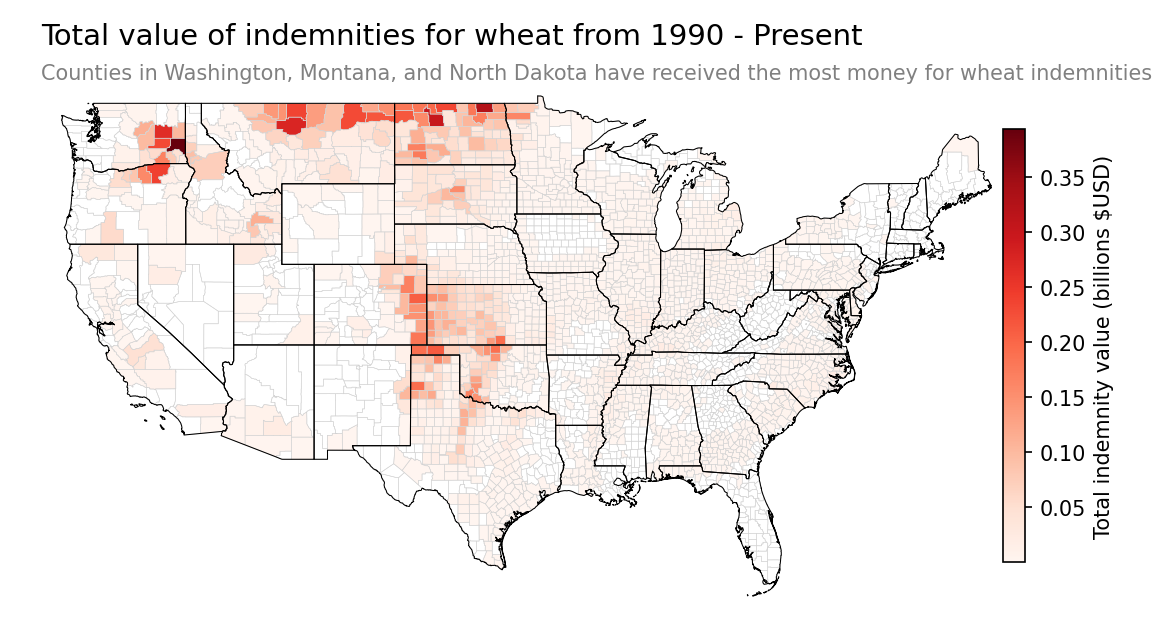

In [20]:
arrow_props = dict(
    color='black', 
    width=0.5, 
    head_width=2, 
    head_length=5,
)

fig, ax = plt.subplots(figsize=(10, 5), dpi=150)

val_indemnities_by_county.plot(column='indemnity', cmap='Reds', ax=ax)
counties.plot(facecolor='none', edgecolor='lightgray', linewidth=0.25, ax=ax)
states.plot(facecolor='none', edgecolor='black', linewidth=0.5, ax=ax)

vmin = val_indemnities_by_county['indemnity'].min()
vmax = val_indemnities_by_county['indemnity'].max()
norm = plt.Normalize(vmin=vmin, vmax=vmax)
mapper = plt.cm.ScalarMappable(cmap='Reds', norm=norm)
cbar = plt.colorbar(mapper, shrink=0.75, ax=ax, pad=-0.03)
cbar.set_ticks(np.arange(0.05e9, 0.40e9, 0.05e9))
cbar.set_ticklabels([f'{val:.2f}' for val in np.arange(0.05, 0.4, 0.05)])
cbar.set_label('Total indemnity value (billions $USD)', fontsize=10)

s = f'Total value of indemnities for {CROP} from 1990 - Present'
ax_text(x=-126, y=53, s=s, size=14, color='black', ha='left')

s = f'Counties in Washington, Montana, and North Dakota have received the most money for {CROP} indemnities'
ax_text(x=-126, y=51, s=s, size=10, color='gray', ha='left')

ax.axis('off')

plt.show()


In [21]:
loss_ratio_by_county = df[['fips', 'county_name', 'loss_ratio']].groupby(by=['fips', 'county_name']).mean()
loss_ratio_by_county = loss_ratio_by_county.sort_values(by='loss_ratio', ascending=False).reset_index()
loss_ratio_by_county = loss_ratio_by_county.merge(counties, on='fips', how='left')[['state', 'name', 'fips', 'loss_ratio', 'geometry']]
loss_ratio_by_county = gpd.GeoDataFrame(loss_ratio_by_county).set_geometry('geometry')
loss_ratio_by_county = loss_ratio_by_county.query(" loss_ratio > 0 ")
loss_ratio_by_county


,state,name,fips,loss_ratio,geometry
0,WV,Hampshire,54027,6.075455,"POLYGON ((-78.336 39.44497, -78.35021 39.42762..."
1,PA,Washington,42125,4.285185,"POLYGON ((-80.51966 39.96249, -80.5197 40.0001..."
2,IA,Montgomery,19137,2.731667,"POLYGON ((-94.92758 41.1585, -94.92845 40.9006..."
3,MS,Oktibbeha,28105,2.684286,"POLYGON ((-89.08825 33.286, -89.08847 33.5332,..."
4,PA,Clearfield,42033,2.478548,"POLYGON ((-78.3599 40.73258, -78.35043 40.7248..."
...,...,...,...,...,...
2056,NM,Luna,35029,0.022500,"POLYGON ((-108.1375 31.77754, -108.16334 31.77..."
2057,NE,Rock,31149,0.017083,"POLYGON ((-99.66237 42.086, -99.66377 42.4345,..."
2058,IL,La Salle,17099,0.015333,"POLYGON ((-89.16378 41.31445, -89.16645 41.483..."
2059,ID,Gem,16045,0.008421,"POLYGON ((-116.28263 43.80682, -116.51351 43.8..."


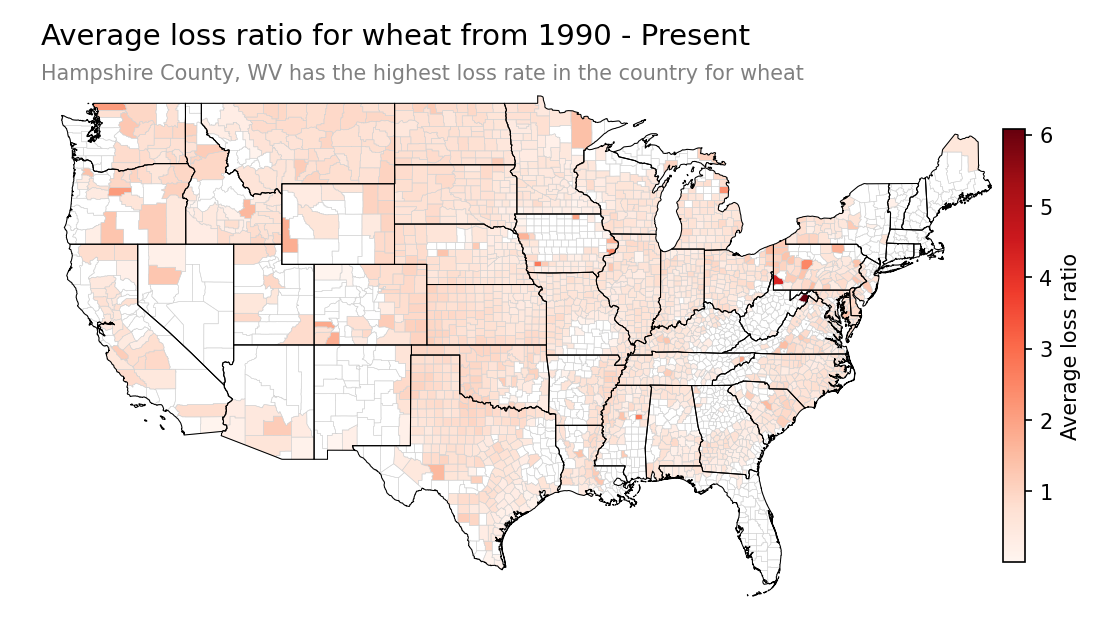

In [22]:
arrow_props = dict(
    color='black', 
    width=0.5, 
    head_width=2, 
    head_length=5,
)

fig, ax = plt.subplots(figsize=(10, 5), dpi=150)

loss_ratio_by_county.plot(column='loss_ratio', cmap='Reds', ax=ax)
counties.plot(facecolor='none', edgecolor='lightgray', linewidth=0.25, ax=ax)
states.plot(facecolor='none', edgecolor='black', linewidth=0.5, ax=ax)

vmin = loss_ratio_by_county['loss_ratio'].min()
vmax = loss_ratio_by_county['loss_ratio'].max()
norm = plt.Normalize(vmin=vmin, vmax=vmax)
mapper = plt.cm.ScalarMappable(cmap='Reds', norm=norm)

cbar = plt.colorbar(mapper, shrink=0.75, ax=ax, pad=-0.03)
cbar.set_label('Average loss ratio')

s = f'Average loss ratio for {CROP} from 1990 - Present'
ax_text(x=-126, y=53, s=s, size=14, color='black', ha='left')

s = f'{loss_ratio_by_county.iloc[0]['name']} County, {loss_ratio_by_county.iloc[0]['state']} has the highest loss rate in the country for {CROP}'
ax_text(x=-126, y=51, s=s, size=10, color='gray', ha='left')

ax.axis('off')

plt.show()
